# Load feature data

In [139]:
import pandas as pd
import matplotlib.pyplot as plt

# load data from weather_features.csv

df = pd.read_csv(
    './weather_features.csv',
    parse_dates=['last_updated']
)
df.shape

(144229, 89)

In [140]:
df.dtypes.value_counts()

int64             60
float64           28
datetime64[us]     1
Name: count, dtype: int64

# Modelling

- Temperature forecasting with only date

## Time Series Modelling

In [141]:
daily = (
    df.groupby(df['last_updated'].dt.date)
      ['temperature_celsius']
      .mean()
      .reset_index()
)

daily.columns = ['date', 'temperature']
daily['date'] = pd.to_datetime(daily['date'])

daily.head()

,date,temperature
0,2024-05-16,23.767196
1,2024-05-17,24.451648
2,2024-05-18,25.355610
3,2024-05-19,25.270103
4,2024-05-20,25.430769


In [142]:
train_size = int(len(daily) * 0.8)

train = daily.iloc[:train_size]
test  = daily.iloc[train_size:]

In [143]:
# Common imports

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

### 7 day Moving Average Forecast

In [144]:
history = train['temperature'].tolist()

pred_ma7 = []

for i in range(len(test)):
    forecast = sum(history[-7:]) / 7
    pred_ma7.append(forecast)
    history.append(test['temperature'].iloc[i])

In [145]:
mae_ma7 = mean_absolute_error(test['temperature'], pred_ma7)
mse_ma7 = mean_squared_error(test['temperature'], pred_ma7)
rmse_ma7 = mse_ma7 ** 0.5
r2_ma7 = r2_score(test['temperature'], pred_ma7)

print(f'MAE  : {mae_ma7:.3f}')
print(f'RMSE : {rmse_ma7:.3f}')
print(f'R²   : {r2_ma7:.3f}')

MAE  : 0.520
RMSE : 1.068
R²   : 0.843


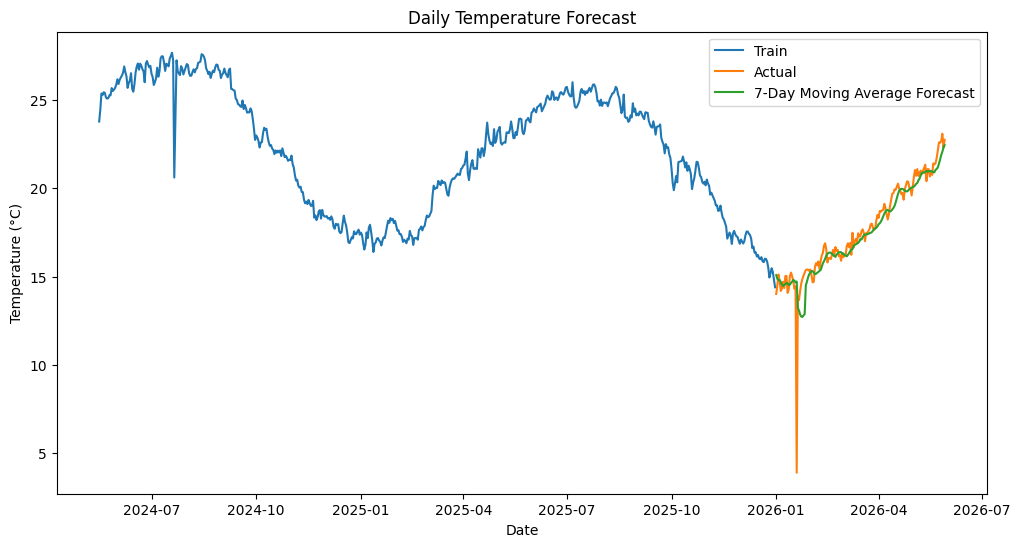

In [146]:
plt.figure(figsize=(12,6))

plt.plot(train['date'], train['temperature'], label='Train')
plt.plot(test['date'], test['temperature'], label='Actual')
plt.plot(test['date'], pred_ma7, label='7-Day Moving Average Forecast')

plt.title('Daily Temperature Forecast')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()

plt.show()

### 3 day Moving Average Forecast

In [147]:
history = train['temperature'].tolist()
pred_ma3 = []

for _ in range(len(test)):
    forecast = sum(history[-3:]) / 3
    pred_ma3.append(forecast)
    history.append(test['temperature'].iloc[len(pred_ma3)-1])

In [148]:
mae_ma3 = mean_absolute_error(test['temperature'], pred_ma3)
mse_ma3 = mean_squared_error(test['temperature'], pred_ma3)
rmse_ma3 = mse_ma3 ** 0.5
r2_ma3 = r2_score(test['temperature'], pred_ma3)

print(f'MAE  : {mae_ma3:.3f}')
print(f'RMSE : {rmse_ma3:.3f}')
print(f'R²   : {r2_ma3:.3f}')

MAE  : 0.458
RMSE : 1.060
R²   : 0.845


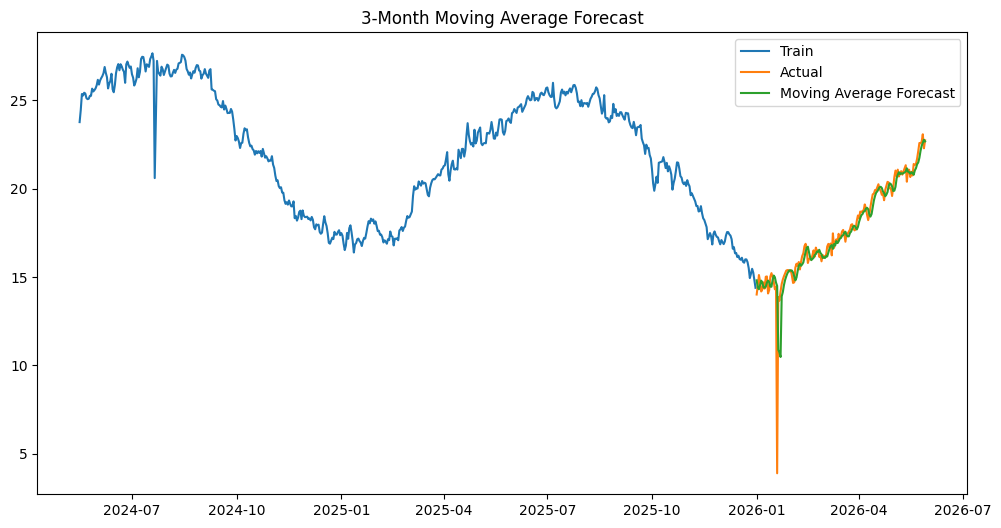

In [149]:
plt.figure(figsize=(12,6))

plt.plot(train['date'], train['temperature'], label='Train')
plt.plot(test['date'], test['temperature'], label='Actual')
plt.plot(test['date'], pred_ma3, label='Moving Average Forecast')

plt.legend()
plt.title('3-Month Moving Average Forecast')

plt.show()

### ARIMA

In [150]:
train_size = int(len(daily) * 0.8)

train = daily[:train_size]
test  = daily[train_size:]

In [151]:
train.dtypes

date           datetime64[s]
temperature          float64
dtype: object

In [152]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(
    train['temperature'],
    order=(1,0,1)
)

model_fit = model.fit()

In [153]:
pred_arima = model_fit.forecast(
    steps=len(test)
)

In [154]:
mae_arima = mean_absolute_error(test['temperature'], pred_arima)
mse_arima = mean_squared_error(test['temperature'], pred_arima)
rmse_arima = mse_arima ** 0.5
r2_arima = r2_score(test['temperature'], pred_arima)

print(f'MAE  : {mae_arima:.3f}')
print(f'RMSE : {rmse_arima:.3f}')
print(f'R²   : {r2_arima:.3f}')

MAE  : 2.374
RMSE : 3.080
R²   : -0.310


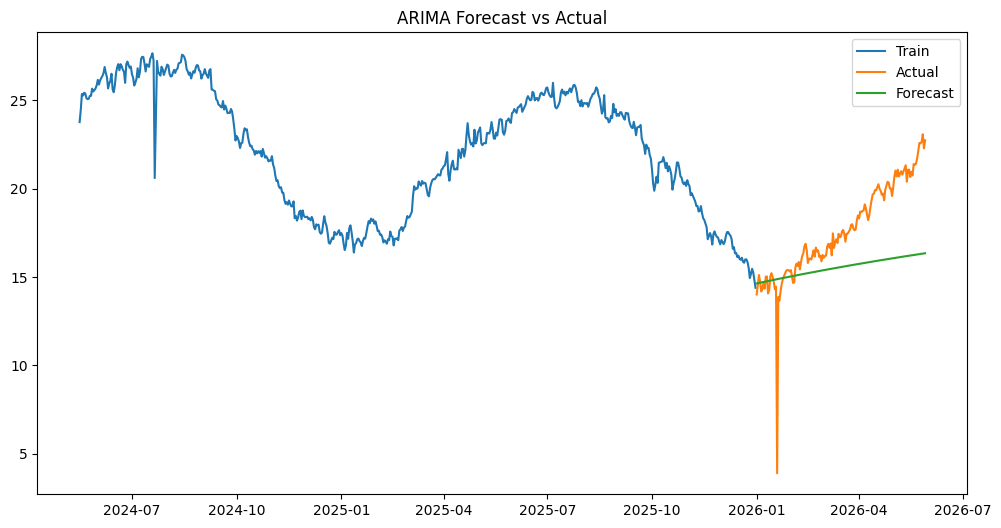

In [155]:
plt.figure(figsize=(12,6))

plt.plot(train['date'], train['temperature'], label='Train')
plt.plot(test['date'], test['temperature'], label='Actual')
plt.plot(test['date'], pred_arima, label='Forecast')

plt.legend()
plt.title('ARIMA Forecast vs Actual')

plt.show()

### Prophet

In [ ]:
from prophet import Prophet

prophet_df = daily[['date', 'temperature']].copy()

prophet_df = prophet_df.rename(columns={
    'date': 'ds',
    'temperature': 'y'
})

prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])
prophet_df = prophet_df.sort_values('ds')

train_size = int(len(prophet_df) * 0.8)

train_prophet = prophet_df.iloc[:train_size]
test_prophet = prophet_df.iloc[train_size:]

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=True
)

model.fit(train_prophet)

future = test_prophet[['ds']]

forecast = model.predict(future)

y_true = test_prophet['y'].values
pred_prophet = forecast['yhat'].values

mae_prophet = mean_absolute_error(y_true, pred_prophet)
mse_prophet = mean_squared_error(y_true, pred_prophet)
rmse_prophet = mse_prophet ** 0.5
r2_prophet = r2_score(y_true, pred_prophet)

print(f'MAE  : {mae_prophet:.3f}')
print(f'RMSE : {rmse_prophet:.3f}')
print(f'R²   : {r2_prophet:.3f}')

12:56:50 - cmdstanpy - INFO - Chain [1] start processing
12:56:50 - cmdstanpy - INFO - Chain [1] done processing


MAE  : 1.193
RMSE : 1.608
R²   : 0.643


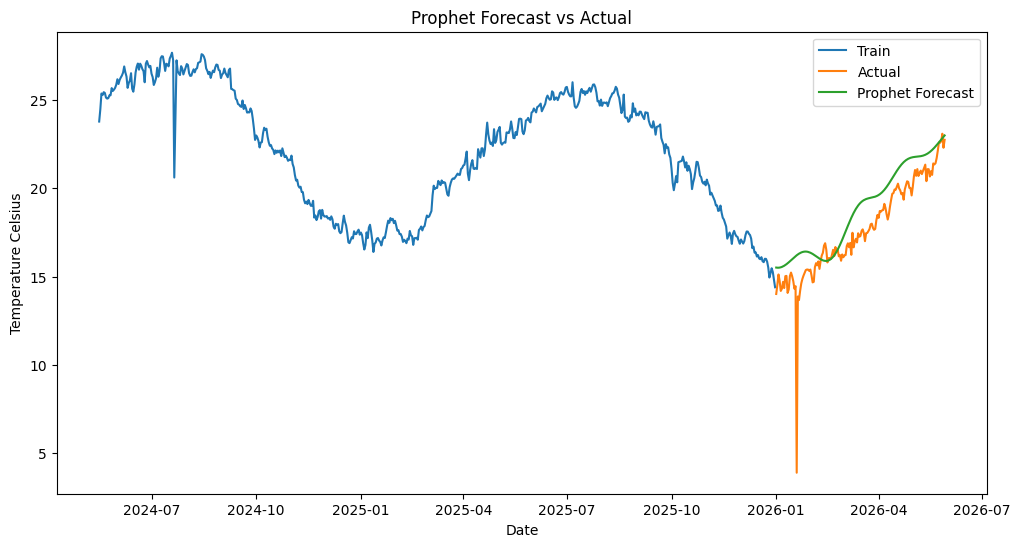

In [157]:
plt.figure(figsize=(12,6))

plt.plot(train['ds'], train['y'], label='Train')
plt.plot(test['ds'], test['y'], label='Actual')
plt.plot(test['ds'], pred_prophet, label='Prophet Forecast')

plt.legend()
plt.title('Prophet Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Temperature Celsius')
plt.show()

## Comparison of Time Series Models

In [159]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 149 entries, 594 to 742
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   ds      149 non-null    datetime64[s]
 1   y       149 non-null    float64      
dtypes: datetime64[s](1), float64(1)
memory usage: 2.5 KB


MA-3    MAE:0.458  RMSE:1.060  R2:0.845
MA-7    MAE:0.520  RMSE:1.068  R2:0.843
ARIMA   MAE:2.374  RMSE:3.080  R2:-0.310
Prophet MAE:1.193  RMSE:1.608  R2:0.643


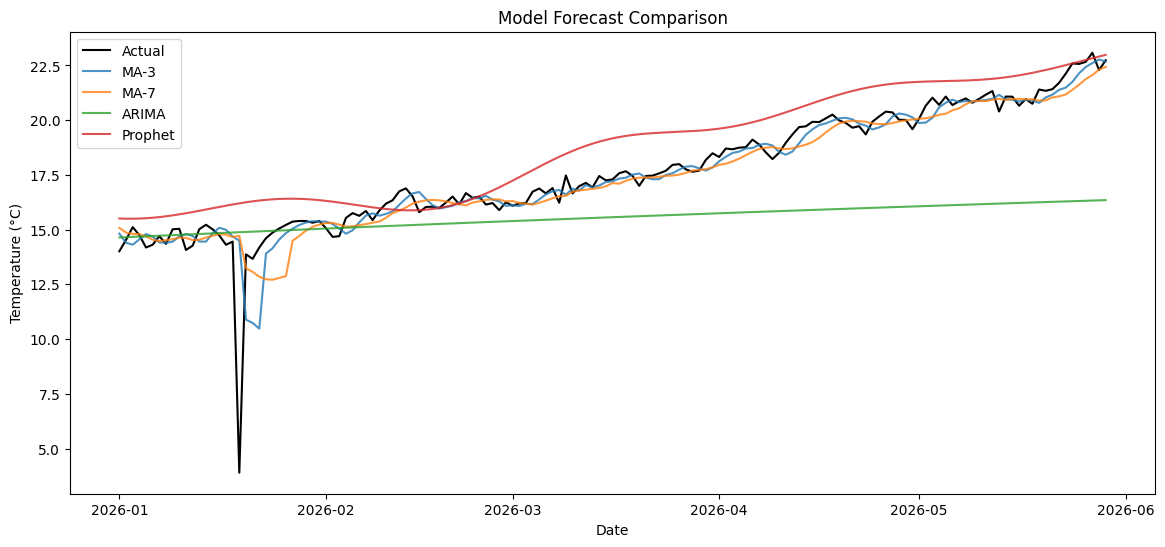

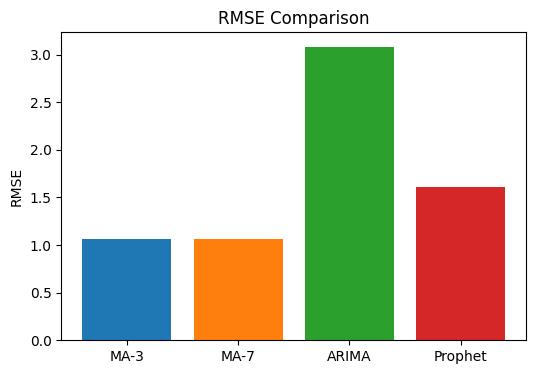

In [ ]:
import numpy as np

# assemble predictions - MA-7 -> `pred_ma7`, MA-3 -> `pred_ma3`, ARIMA -> `forecast`, Prophet -> `y_pred`
pred_ma7_arr = np.asarray(pred_ma7)
pred_ma3_arr = np.asarray(pred_ma3)
pred_arima_arr = np.asarray(pred_arima)
pred_prophet_arr = np.asarray(pred_prophet)

y_true = test['temperature'].values

print(f'MA-3    MAE:{mae_ma3:.3f}  RMSE:{rmse_ma3:.3f}  R2:{r2_ma3:.3f}')
print(f'MA-7    MAE:{mae_ma7:.3f}  RMSE:{rmse_ma7:.3f}  R2:{r2_ma7:.3f}')
print(f'ARIMA   MAE:{mae_arima:.3f}  RMSE:{rmse_arima:.3f}  R2:{r2_arima:.3f}')
print(f'Prophet MAE:{mae_prophet:.3f}  RMSE:{rmse_prophet:.3f}  R2:{r2_prophet:.3f}')

# plot comparison
plt.figure(figsize=(14,6))
plt.plot(test['ds'], y_true, label='Actual', color='k')
plt.plot(test['ds'], pred_ma3_arr, label='MA-3', alpha=0.8)
plt.plot(test['ds'], pred_ma7_arr, label='MA-7', alpha=0.8)
plt.plot(test['ds'], pred_arima_arr, label='ARIMA', alpha=0.8)
plt.plot(test['ds'], pred_prophet_arr, label='Prophet', alpha=0.8)
plt.legend()
plt.title('Model Forecast Comparison')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.show()

# RMSE bar chart
models = ['MA-3','MA-7','ARIMA','Prophet']
rmses = [rmse_ma3, rmse_ma7, rmse_arima, rmse_prophet]
plt.figure(figsize=(6,4))
plt.bar(models, rmses, color=['C0','C1','C2','C3'])
plt.title('RMSE Comparison')
plt.ylabel('RMSE')
plt.show()